# Reinforcement learning cycle — *KON-Artist model*

### Objective: Adversarial DSP Pipeline for Audio Spoofing Detection

This notebook implements a non-differentiable, black-box audio generation pipeline designed for Reinforcement Learning (RL). The objective is to bridge the "naturalness gap" between synthetic and bonafide speech by simulating physiological and environmental artifacts. By manipulating micro-prosody (jitter/shimmer), spectral envelopes (tilt/harmonics), and channel degradations (codecs), the pipeline provides a search space for an RL Actor to expose structural vulnerabilities in modern Graph Attention-based detectors like AASIST3.

### Requirements

In [ ]:
!pip install gymnasium stable_baselines3

In [ ]:
# --- STEP 1: TOTAL CLEANUP ---
# Uninstall everything to avoid conflicts between versions 2.5 and 2.11
!pip uninstall -y torch torchaudio torchvision torchcodec torchfx nvidia-nccl-cu12 nvidia-cudnn-cu12

# Physical deletion of folders to avoid "circular import" and "partially initialized" errors
!rm -rf /usr/local/lib/python3.12/dist-packages/torch*
!rm -rf /usr/local/lib/python3.12/dist-packages/nvidia*
!pip cache purge

# --- STEP 2: SYSTEM DEPENDENCIES ---
# Install FFmpeg and the development libraries required by torchcodec and torchaudio
!apt-get update && apt-get install -y ffmpeg libavcodec-dev libavformat-dev libavutil-dev

# --- STEP 3: COORDINATED INSTALLATION (CUDA 12.1) ---
# Use version 2.5.1, which is currently the most stable for research
!pip install torch==2.5.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

# --- STEP 4: AUDIO LIBRARIES ---
# Install torch_audiomentations and torchcodec compatible with 2.5.1
!pip install torch-audiomentations==0.12.0
!pip install torchcodec==0.2.0

# Librosa is optional, but we include it if analysis utilities needed
#!pip install librosa

# Reinforcement Learning Environment

In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class AudioAttackEnv(gym.Env):
    def __init__(self, model_aasist, dsp_pipeline, audio_samples):
        super(AudioAttackEnv, self).__init__()
        self.model = model_aasist
        self.dsp = dsp_pipeline
        self.audio_data = audio_samples # Lista de audios bonafide/spoof

        # Espacio de acciones: [Tilt_Gain, Comp_Threshold, Jitter_Level, Shimmer_Level]
        # Definimos rangos normalizados de -1 a 1 para facilitar el aprendizaje
        self.action_space = spaces.Box(low=-1, high=1, shape=(7,), dtype=np.float32)

        # Espacio de observación: Embeddings de AASIST3 (ej. tamaño 160)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(160,), dtype=np.float32)

    def _denormalize(self, action):
        """
        Maps actions from [-1, 1] to the physical ranges of the DSP pipeline.
        """
        # Define boundaries (Constants or class attributes)
        ranges = {
            'jitter':    (0.0, 0.05),    # Limit variance to 50ms for realism
            'shimmer':   (0.0, 0.2),     # 20% amplitude modulation
            'tilt':      (-5.0, 5.0),    # [dB/octave]
            'harmonics': (0.0, 2.0),     # Drive/Saturation factor
            'threshold': (-60.0, 0.0),   # [dB]
            'ratio':     (1.0, 20.0),    # Compression ratio
            'bitrate':   (8000, 320000)  # From Telephone to Audio Streaming values [bps]
                                         # 8kbps (Telephony/AMR) to 320kbps (Max MP3/Ogg)
        }

        # Mapping helpers [-1, 1] -> [low, high]
        def map_linear(val, low, high):
            return low + (val + 1.0) * 0.5 * (high - low)
        def map_log(val, low, high):
            # Ensure low/high are positive and > 0 for log scaling
            alpha = (val + 1.0) / 2.0
            return low * (high / low) ** alpha

        # Define ranges
        # Note: 'threshold' and 'tilt' are in dB, so linear mapping here results in a log-scale change in raw amplitude.
        params = {
            'jitter':    map_linear(action[0], *ranges['jitter']),
            'shimmer':   map_linear(action[1], *ranges['shimmer']),
            'tilt':      map_linear(action[2], *ranges['tilt']),
            'harmonics': map_linear(action[3], *ranges['harmonics']),
            'threshold': map_linear(action[4], *ranges['threshold']),
            # 'ratio' and 'bitrate' benefit significantly from log-scaling
            'ratio':     map_log(action[5], *ranges['ratio']),
            'bitrate':   int(map_log(action[6], *ranges['bitrate'])) # Cast to int for codec
        }

        return params

    def step(self, action):
        # 1. Denormalizar acción a parámetros reales del DSP
        params = self._denormalize(action)

        # 2. Aplicar DSP al audio actual
        processed_audio = self.dsp(self.current_audio, params)

        # 3. Obtener predicción de AASIST3
        with torch.no_grad():
            logits, embedding = self.model(processed_audio)
            probs = torch.softmax(logits, dim=-1)

        # 4. Calcular Reward (Queremos que el modelo crea que es Bonafide)
        # Asumiendo índice 1 = Bonafide
        reward = probs[0, 1].item()

        # 5. La observación es el nuevo embedding generado
        observation = embedding.cpu().numpy()

        # En este caso, cada audio es un "episodio" de un solo paso o N pasos
        terminated = True
        return observation, reward, terminated, False, {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Seleccionar un nuevo audio del dataset para el siguiente intento
        self.current_audio = self._get_next_audio()
        # Obtener embedding inicial
        _, embedding = self.model(self.current_audio)
        return embedding.detach().cpu().numpy(), {}

# Learning Cycle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Preparation

In [ ]:
from stable_baselines3.common.env_checker import check_env

# Initialize our components
model_aasist = ... # Our pretrained model
dsp_pipeline = ... # Our DSP function
audio_samples = ... # Our dataset

env = AudioAttackEnv(model_aasist, dsp_pipeline, audio_samples)

# It will raise an error or warning if the observation/action spaces are inconsistent
check_env(env)

### Train

In [ ]:
from stable_baselines3 import PPO

# 1. Instantiate the agent
# 'MlpPolicy' uses a standard Multi-Layer Perceptron for the actor and critic
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048, # Batch size for updates
    batch_size=64
)

# 2. Run the learning process
# total_timesteps is the number of 'step()' calls
model.learn(total_timesteps=10000)

# 3. Save the trained policy
model.save("audio_attacker_ppo")

In [ ]:
# Resolving the Gymnasium Warning
# pip install "stable-baselines3>=2.0.0"

### Evaluation

In [ ]:
# 1. Instantiate the pipeline
pipeline = AdvancedDSPPipeline(sample_rate=sr)

# 2. Define the parameters (RL Actions)
# These should be mapped from the agent's [-1, 1] output to real ranges
params = {
    'jitter': 0.001,     # Micro-delay variance
    'shimmer': 0.02,     # Amplitude modulation intensity
    'tilt': -2.5,        # dB per octave slope
    'harmonics': 0.5,    # Saturation drive
    'threshold': -20.0,  # Compressor threshold in dB
    'ratio': 4.0,        # Compressor ratio
    'bitrate': 64000     # Codec settings
}

In [ ]:
# Convert numpy array to torch tensor
if isinstance(audio, np.ndarray):
    audio_tensor = torch.from_numpy(audio).float()
else:
    audio_tensor = audio.float()

# Ensure audio has a batch dimension [1, Channels, Samples] or [1, Samples]
if audio_tensor.dim() == 1:
    # [Samples] -> [1, 1, Samples]
    audio_input = audio_tensor.unsqueeze(0).unsqueeze(0)
elif audio_tensor.dim() == 2:
    # [Channels, Samples] -> [1, Channels, Samples]
    audio_input = audio_tensor.unsqueeze(0)
else:
    audio_input = audio_tensor

# Apply the pipeline
# The pipeline expectation is (Channels, Samples) after the initial squeeze
processed_audio = pipeline(audio_input.squeeze(0), params)

# Result is [Channels, Samples]
print(f"Original shape: {audio.shape}")
print(f"Processed shape: {processed_audio.shape}")

Original shape: torch.Size([550936])
Processed shape: torch.Size([1, 550936])


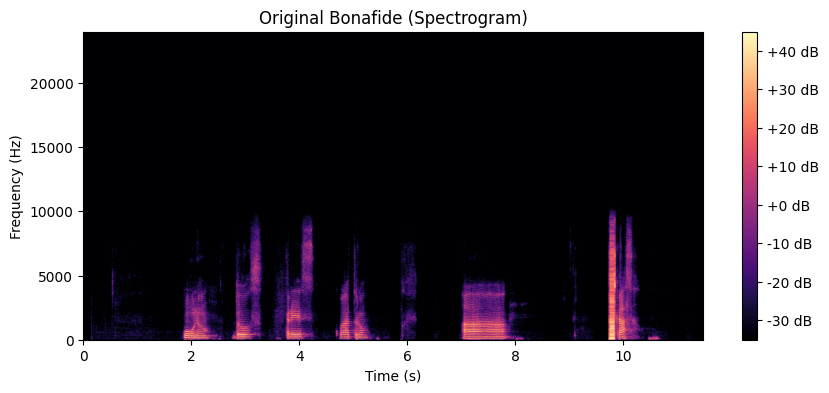

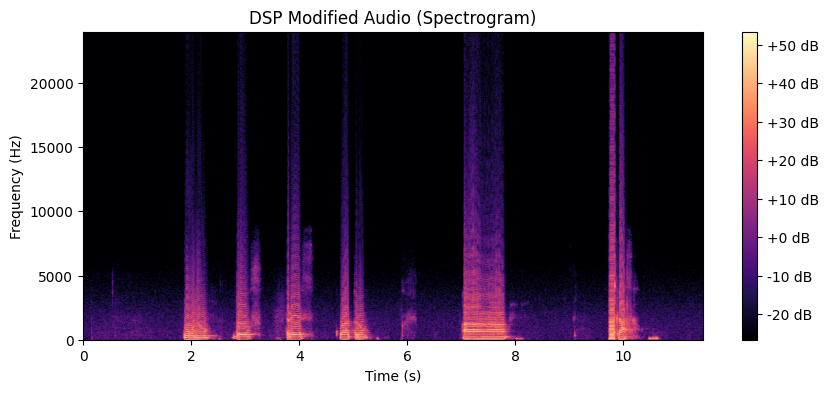

In [ ]:
# Compare Original vs Processed
show_spect(audio_input.squeeze(0), sr, title="Original Bonafide")
show_spect(processed_audio.squeeze(0), sr, title="DSP Modified Audio")

In [ ]:
Audio(processed_audio, rate=sr)

### Convergence Plot

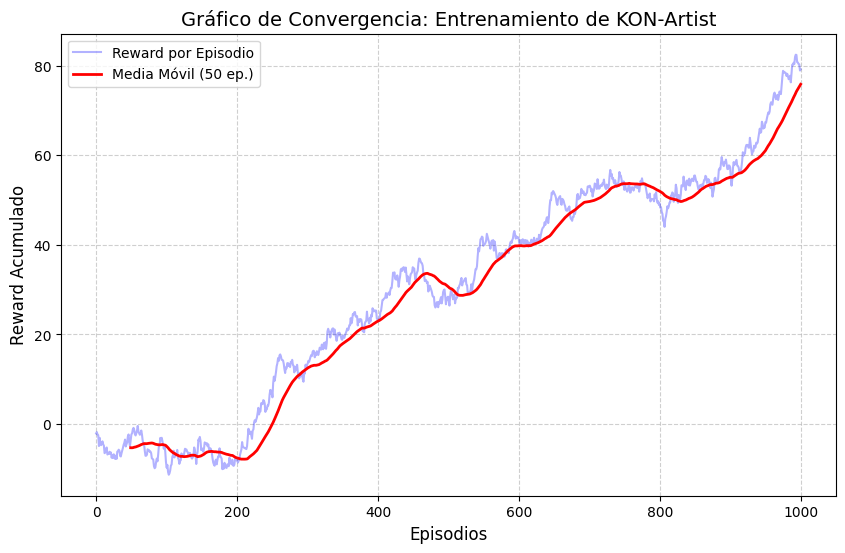

In [ ]:
def plot_convergence(rewards, window_size=50):
    """
    Generates the convergence plot
    """
    plt.figure(figsize=(10, 6))

    # 1. Plot raw rewards (using transparency to avoid visual clutter)
    plt.plot(rewards, alpha=0.3, color='blue', label='Reward per Episode')

    # 2. Calculate and plot the Moving Average (Smoothing)
    if len(rewards) >= window_size:
        # Utilizing pandas for efficient moving average calculation
        moving_avg = pd.Series(rewards).rolling(window=window_size).mean()
        plt.plot(moving_avg, color='red', linewidth=2, label=f'Moving Average ({window_size} ep.)')

    # Label configuration based on FIUBA requirements
    plt.title('Convergence Plot: KON-Artist Training', fontsize=14)
    plt.xlabel('Episodes', fontsize=12)
    plt.ylabel('Accumulated Reward', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Save for the submission PDF
    plt.savefig('rl_convergence_fiuba.pdf')
    plt.show()

# Example usage with simulated data
total_episodes = 1000
mock_rewards = np.cumsum(np.random.randn(total_episodes)) + np.linspace(0, 100, total_episodes)
# rewards_per_episode = [r1, r2, r3, ...] # Rewards list shape after training
plot_convergence(mock_rewards)